In [33]:
import os, sys
os.environ["MPICH_GPU_SUPPORT_ENABLED"] = "0"
import random
import fitsio
import numpy as np
from astropy.table import Table,join,unique,vstack
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import ticker
from mockfactory import Catalog
import random

sys.path.append('../../')
from helper import REDSHIFT_BIN_LSS
%load_ext autoreload
%autoreload 2

from LSS.globals import main
import LSS.common_tools as common

outdir = '/pscratch/sd/s/shengyu/repeats/DA2/loa-v1'
OVERLEAF_DIR = '../../../overleaf/figures'


def get_repeats(indat, labels = None):
    if labels is None:
        labels = ['Z']
    tids,cnts = np.unique(indat['TARGETID'],return_counts=True)
    rtids = tids[cnts>1]
    sel_r = np.isin(indat['TARGETID'],rtids)
    specflr = indat[sel_r]
    print("N rows with TARGETID repeated:", len(specflr))
    specflr.sort("TARGETID")
    out = {'TARGETID': []}
    for lab in labels:
        out[f'{lab}_1'] = []
        out[f'{lab}_2'] = []
    ind = 0
    n = len(specflr)
    while ind < n:
        row1 = specflr[ind]
        tid = row1['TARGETID']
        ind2 = 1
        while ind + ind2 < n and specflr[ind + ind2]['TARGETID'] == tid:
            row2 = specflr[ind + ind2]
            out['TARGETID'].append(tid)
            for lab in labels:
                out[f'{lab}_1'].append(row1[lab])
                out[f'{lab}_2'].append(row2[lab])
            ind2 += 1
        ind += ind2
        if ind % 100000 == 0:
            print("processed", ind)
    return Table(out)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
fn = '/dvs_ro/cfs/projectdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v1/LRG_full.dat.fits'
# fn = '/dvs_ro/cfs/projectdirs/desi/survey/catalogs/DA2/LSS/loa-v1/datcomb_dark_spec_zdone.fits'
data = Catalog.read(fn)
print(data)
print()

# targetids = data['TARGETID']
# data["TARGETID"]

Catalog(csize=6251937, size=6251937, columns=['TARGETID', 'MWS_TARGET', 'SUBPRIORITY', 'PRIORITY_INIT', 'TARGET_STATE', 'TIMESTAMP', 'PRIORITY', 'LOCATION', 'TILEID', 'TILELOCID', 'LASTNIGHT', 'Z_not4clus', 'ZERR', 'ZWARN', 'CHI2', 'COEFF', 'NPIXELS', 'SPECTYPE', 'SUBTYPE', 'NCOEFF', 'DELTACHI2', 'FIBER', 'COADD_FIBERSTATUS', 'FIBERASSIGN_X', 'FIBERASSIGN_Y', 'COADD_NUMEXP', 'COADD_EXPTIME', 'COADD_NUMNIGHT', 'MEAN_DELTA_X', 'RMS_DELTA_X', 'MEAN_DELTA_Y', 'RMS_DELTA_Y', 'MEAN_PSF_TO_FIBER_SPECFLUX', 'TSNR2_BGS_B', 'TSNR2_ELG_B', 'TSNR2_LRG_B', 'TSNR2_LYA_B', 'TSNR2_QSO_B', 'TSNR2_BGS_R', 'TSNR2_ELG_R', 'TSNR2_LRG_R', 'TSNR2_LYA_R', 'TSNR2_QSO_R', 'TSNR2_BGS_Z', 'TSNR2_ELG_Z', 'TSNR2_LRG_Z', 'TSNR2_LYA_Z', 'TSNR2_QSO_Z', 'TSNR2_BGS', 'TSNR2_ELG', 'TSNR2_LRG', 'TSNR2_LYA', 'TSNR2_QSO', 'ZWARN_MTL', 'Z_QN', 'Z_QN_CONF', 'IS_QSO_QN', 'PRIORITY_ASSIGNED', 'GOODPRI', 'GOODHARDLOC', 'LOCATION_ASSIGNED', 'TILELOCID_ASSIGNED', 'NTILE', 'TILES', 'BRICKID', 'BRICKNAME', 'MORPHTYPE', 'RA', 'DEC', 

(array([2.818100e+04, 1.528811e+06, 2.952031e+06, 5.614700e+05,
        6.251600e+04, 8.370000e+03, 3.455000e+03, 2.261000e+03,
        5.130000e+02, 7.800000e+01]),
 array([ 40.82984  60.08244  79.33504  98.58763 117.84023 137.09283 156.34543
  175.59802 194.85062 214.10323 233.35582]),
 <BarContainer object of 10 artists>)

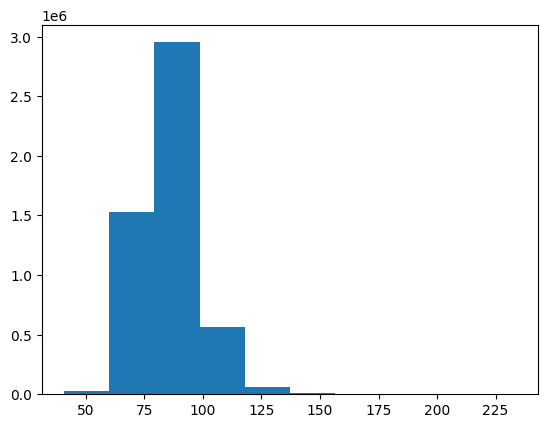

In [3]:
sel = (data['TSNR2_LRG']<1000)
plt.hist(data['TSNR2_LRG'][sel])

In [ ]:
plt.hist(data['CHI2'])


(array([2.9482500e+05, 1.4688700e+05, 7.8538550e+06, 1.6894514e+07,
        2.4594070e+06, 2.9415300e+05, 4.5322000e+04, 7.9060000e+03,
        1.1710000e+03, 1.7500000e+02]),
 array([  0.        38.332188  76.664375 114.99656  153.32875  191.66093
  229.99312  268.32532  306.6575   344.9897   383.32187 ]),
 <BarContainer object of 10 artists>)

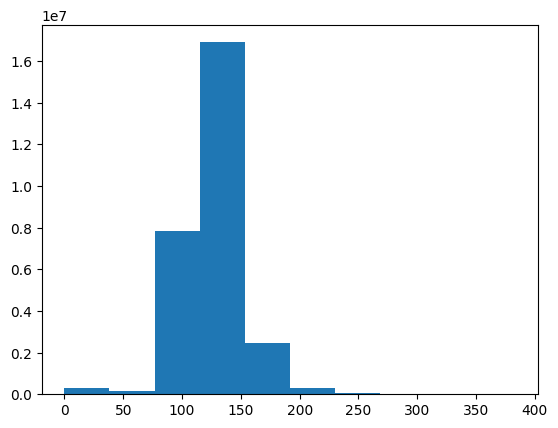

In [30]:
plt.hist(data['TSNR2_ELG'])

## For dark tracers

In [5]:
survey = 'DA2'
time = 'dark'

mainp = main('LRG', 'loa-v1')#get settings for dark time

mt = mainp.mtld
tiles = mainp.tiles
imbits = mainp.imbits #mask bits applied to targeting
ebits = mainp.ebits #extra mask bits we think should be applied

tsnrcut = mainp.tsnrcut
dchi2 = mainp.dchi2
tnsrcol = mainp.tsnrcol        
zmin = mainp.zmin
zmax = mainp.zmax
badfib = mainp.badfib

#get set of tiles
wd = mt['SURVEY'] == 'main'
wd &= mt['ZDONE'] == 'true'
wd &= mt['FAPRGRM'] == time
if survey == 'Y1':
    wd &= mt['ZDATE'] < 20220900
if survey == 'DA2':
    wd &= mt['ZDATE'] < 20240410
mtld = mt[wd]

# for tracer
ldirspec = '/dvs_ro/cfs/cdirs/desi/survey/catalogs/'+f'{survey}'+'/LSS/'+'loa-v1'+'/'
specfo = ldirspec+f'datcomb_{time}_spec_zdone.fits'
specf = Table(fitsio.read(specfo))
sel = np.isin(specf['TILEID'],mtld['TILEID'])
specf = specf[sel]
specf = Table(specf)
specf.keep_columns(['TARGETID','Z','ZWARN','ZERR', 'DELTACHI2','LOCATION','DESI_TARGET','TILEID','TSNR2_LRG','TSNR2_ELG', 'TSNR2_QSO', 'ZWARN_MTL','COADD_FIBERSTATUS','FIBER','LASTNIGHT', 'Z_QN','Z_QN_CONF','IS_QSO_QN' ])
specf = common.cut_specdat(specf,badfib=mainp.badfib_td,tsnr_min=tsnrcut,tsnr_col=tnsrcol,fibstatusbits=mainp.badfib_status,remove_badfiber_spike_nz=True,mask_petal_nights=True)

LRG


number with no data 114111
number with bad qa 730556
number at low tsnr2 487520
will mask fibers with time dependence
number removed from time dependent mask is 411848
number removed from spike mask is 56226
number removed from petal night mask is 133031


In [19]:
specf

TARGETID,LASTNIGHT,Z,ZERR,ZWARN,DELTACHI2,LOCATION,FIBER,COADD_FIBERSTATUS,DESI_TARGET,TILEID,TSNR2_ELG,TSNR2_LRG,TSNR2_QSO,ZWARN_MTL,Z_QN,Z_QN_CONF,IS_QSO_QN
int64,int32,float64,float64,int64,float64,int64,int32,int32,int64,int32,float32,float32,float32,int64,float64,float64,int16
2204596575404032,20211207,0.9202842403601226,8.215467697228755e-05,4,6.247507736086845,7231,3696,0,4611686018427387904,5843,149.73386,100.694695,33.79132,4,2.1043300258932427,0.0011781915615822337,0
2204623473475584,20240109,0.18525533312667702,6.52643938379786e-05,4,0.6904128678143024,187,29,0,4611686018427387904,6271,110.81747,75.89079,27.704742,4,0.9887578312190795,7.508927148918077e-05,0
2204652607111168,20220309,0.016411489188294572,3.191587475369417e-05,0,24.80390017834725,7423,3771,0,4611686018427387904,10367,147.25053,93.63391,30.293745,0,1.7035186598092165,0.010176743245881605,0
2204698811564032,20221027,1.4071094922636993,0.00012600868959775256,4,0.7681537866592407,5227,2599,0,4611686018427387904,9492,128.25554,87.42097,30.562073,4,1.590997353036471,0.002710550342419712,0
2204712820539392,20220301,0.016040149651302335,2.3910465384871773e-05,0,22.177696721395478,3425,1767,0,4611686018427387904,2558,113.28457,78.879616,23.58123,0,1.6467931095079722,0.048941458323948105,0
2204728519819264,20211008,0.4540019230769707,6.778581023548571e-05,4,4.886444889008999,7087,3979,0,4611686018427387904,1154,113.35596,77.30165,31.76311,4,1.8195670332322287,0.0006004674747686866,0
2204728519819264,20230811,0.957850132167,9.628853805861223e-05,4,0.028908050036989152,234,32,0,4611686018427387904,10945,106.028465,77.431335,29.988216,4,2.1602167872918034,0.010017138502105413,0
2204739815079936,20220924,1.1776288678684068,0.0001110576993158109,4,1.889523059129715,2265,1338,0,4611686018427387904,11237,125.48263,84.69672,33.359737,4,1.932610405961769,0.4180600009749265,0
2204743308935168,20220306,0.03313254973460166,4.098895526668919e-05,0,10.253139491425827,9209,4911,0,4611686018427387904,2848,124.665565,81.85579,28.181976,0,1.7067155034256958,0.0039002353330136025,0


In [6]:
tracer = 'LRG'
zcol = 'Z_QF' if tracer == 'QSO' else 'Z'
labels = [zcol, f'TSNR2_{tracer}', 'TILEID', 'ZWARN', 'ZERR', 'DELTACHI2']

sel_LRG = (specf['DESI_TARGET']) & 1 > 0
sel_gz = common.goodz_infull('LRG',specf,zcol='Z')
specfl = specf[sel_LRG&sel_gz]

lrgr = Table.read(outdir+f'/{tracer}repeats_info.fits')
# lrgr = get_repeats(specfl,labels=labels)
# lrgr.write(outdir+f'/{tracer}repeats_info.fits',overwrite=True)

In [7]:
tracer = 'ELG'
zcol = 'Z_QF' if tracer == 'QSO' else 'Z'
labels = [zcol, f'TSNR2_{tracer}', 'TILEID', 'ZWARN', 'ZERR', 'DELTACHI2']

elgf = fitsio.read(mainp.elgzf,columns=['TARGETID','LOCATION','TILEID','OII_FLUX','OII_FLUX_IVAR'])
specfe_ = join(specf,elgf,keys=['TARGETID','TILEID','LOCATION'],join_type='left')
o2c = np.log10(specfe_['OII_FLUX'] * np.sqrt(specfe_['OII_FLUX_IVAR']))+0.2*np.log10(specfe_['DELTACHI2'])
w = (o2c*0) != 0
w |= specfe_['OII_FLUX'] < 0
o2c[w] = -20
specfe_['o2c'] = o2c
sel_ELG = (specfe_['DESI_TARGET'] & 2) > 0
sel_gz = common.goodz_infull('ELG',specfe_,zcol='Z')
specfe = specfe_[sel_ELG&sel_gz]

elgr = Table.read(outdir+f'/{tracer}repeats_info.fits')
# elgr = get_repeats(specfe, labels=labels)
# elgr.write(outdir+f'/{tracer}repeats_info.fits',overwrite=True)

/tmp/ipykernel_2085207/3547978879.py:7: RuntimeWarning: divide by zero encountered in log10
  o2c = np.log10(specfe_['OII_FLUX'] * np.sqrt(specfe_['OII_FLUX_IVAR']))+0.2*np.log10(specfe_['DELTACHI2'])
/tmp/ipykernel_2085207/3547978879.py:7: RuntimeWarning: invalid value encountered in log10
  o2c = np.log10(specfe_['OII_FLUX'] * np.sqrt(specfe_['OII_FLUX_IVAR']))+0.2*np.log10(specfe_['DELTACHI2'])
/tmp/ipykernel_2085207/3547978879.py:8: RuntimeWarning: invalid value encountered in multiply
  w = (o2c*0) != 0


In [8]:
tracer = 'QSO'
zcol = 'Z_QF' if tracer == 'QSO' else 'Z'
labels = [zcol, f'TSNR2_{tracer}', 'TILEID', 'ZWARN', 'ZERR', 'DELTACHI2']

qsof = fitsio.read(mainp.qsozf,columns=['TARGETID','LOCATION','TILEID','Z'])
specfq_ = join(specf,qsof,keys=['TARGETID','TILEID','LOCATION'],join_type='left',uniq_col_name='{col_name}{table_name}',table_names=['','_QF'])
selqso = specfq_['Z_QF']!=999999
selqso &= (specfq_['DESI_TARGET'] & 4) > 0
specfq = specfq_[selqso]

qsor = Table.read(outdir+f'/{tracer}repeats_info.fits')
# qsor = get_repeats(specfq, labels=labels)
# qsor.write(outdir+f'/{tracer}repeats_info.fits',overwrite=True)

## For bright tracers

In [9]:
survey = 'DA2'
time = 'bright'

mainp = main('BGS', 'loa-v1')#get settings for bright time

mt = mainp.mtld
tiles = mainp.tiles
imbits = mainp.imbits #mask bits applied to targeting
ebits = mainp.ebits #extra mask bits we think should be applied

tsnrcut = mainp.tsnrcut
dchi2 = mainp.dchi2
tnsrcol = mainp.tsnrcol        
zmin = mainp.zmin
zmax = mainp.zmax
badfib = mainp.badfib

#get set of tiles
wd = mt['SURVEY'] == 'main'
wd &= mt['ZDONE'] == 'true'
wd &= mt['FAPRGRM'] == time
if survey == 'Y1':
    wd &= mt['ZDATE'] < 20220900
if survey == 'DA2':
    wd &= mt['ZDATE'] < 20240410
mtld = mt[wd]

# for tracer
ldirspec = '/global/cfs/cdirs/desi/survey/catalogs/'+f'{survey}'+'/LSS/'+'loa-v1'+'/'
specfo_ = ldirspec+f'datcomb_{time}_spec_zdone.fits'
specf_ = Table(fitsio.read(specfo_.replace('global','dvs_ro')))
sel = np.isin(specf_['TILEID'],mtld['TILEID'])
specf_ = specf_[sel]
specf_ = Table(specf_)
# specf_.keep_columns(['TARGETID','Z','ZWARN','ZERR', 'DELTACHI2','LOCATION','BGS_TARGET','TILEID','TSNR2_BGS','TSNR2_ELG','ZWARN_MTL','COADD_FIBERSTATUS','FIBER','LASTNIGHT'])
specf_ = common.cut_specdat(specf_,badfib=mainp.badfib_td,tsnr_min=tsnrcut,tsnr_col=tnsrcol,fibstatusbits=mainp.badfib_status,remove_badfiber_spike_nz=True,mask_petal_nights=True)

BGS


number with no data 86136
number with bad qa 508781
number at low tsnr2 453265
will mask fibers with time dependence
number removed from time dependent mask is 317259
number removed from spike mask is 42775
number removed from petal night mask is 23826


In [10]:
mask = (specf_['TARGETID'] == 39627727757644552)
sel_BGS = specf_['BGS_TARGET'] > 0
specf_[mask&sel_BGS]

TARGETID,LASTNIGHT,Z,ZERR,ZWARN,CHI2,COEFF,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,LOCATION,FIBER,COADD_FIBERSTATUS,TARGET_RA,TARGET_DEC,FIBERASSIGN_X,FIBERASSIGN_Y,PRIORITY,DESI_TARGET,BGS_TARGET,TILEID,COADD_NUMEXP,COADD_EXPTIME,COADD_NUMNIGHT,MEAN_DELTA_X,RMS_DELTA_X,MEAN_DELTA_Y,RMS_DELTA_Y,MEAN_PSF_TO_FIBER_SPECFLUX,TSNR2_BGS_B,TSNR2_ELG_B,TSNR2_LRG_B,TSNR2_LYA_B,TSNR2_QSO_B,TSNR2_BGS_R,TSNR2_ELG_R,TSNR2_LRG_R,TSNR2_LYA_R,TSNR2_QSO_R,TSNR2_BGS_Z,TSNR2_ELG_Z,TSNR2_LRG_Z,TSNR2_LYA_Z,TSNR2_QSO_Z,TSNR2_BGS,TSNR2_ELG,TSNR2_LRG,TSNR2_LYA,TSNR2_QSO,ZWARN_MTL,Z_QN,Z_QN_CONF,IS_QSO_QN
int64,int32,float64,float64,int64,float64,float64[10],int64,str6,str20,int64,float64,int64,int32,int32,float64,float64,float32,float32,int32,int64,int64,int32,int16,float32,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int64,float64,float64,int16
39627727757644552,20210603,0.28605946469628174,9.198213390713147e-06,0,8045.786234855652,143.2864882364516 .. -4.367489734044751,7928,GALAXY,,10,522.2704429626465,4378,2190,0,204.46622019151852,-2.5503565184912986,253.21628,250.50107,2000,1152921504606846976,65537,20120,2,964.9967,2,-0.0145,0.014713939,-0.003,0.005830952,0.7481759,127.86466,0.021860672,0.27160963,11.332578,0.51850194,966.18896,9.477605,14.202571,0.023305643,2.593621,1530.1909,29.322514,14.821446,0.0,5.65003,2624.2446,38.82198,29.295628,11.355884,8.762154,0,3.2964683614709323,0.46435915805572214,0
39627727757644552,20220314,1.6477375766567535,2.137333635345514e-05,0,8586.428625106812,1152.3566646141471 .. 41.8019101974451,7832,GALAXY,,10,191.55810737609863,6057,3323,0,204.46622019151852,-2.5503565184912986,-73.4424,125.3221,2,1152921504606846976,65537,23728,1,799.9182,1,0.01019535,0.01019535,-0.0011595977,0.0011595977,0.76974344,84.14863,0.014535021,0.16222425,10.792868,0.39138868,420.24655,5.4973283,7.429301,0.006210314,1.5307702,1070.4338,26.36167,11.431301,0.0,5.3412204,1574.829,31.873533,19.022827,10.799078,7.263379,0,1.2739415614305245,0.0012299088493887252,0


In [11]:
specf_

TARGETID,LASTNIGHT,Z,ZERR,ZWARN,CHI2,COEFF,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,LOCATION,FIBER,COADD_FIBERSTATUS,TARGET_RA,TARGET_DEC,FIBERASSIGN_X,FIBERASSIGN_Y,PRIORITY,DESI_TARGET,BGS_TARGET,TILEID,COADD_NUMEXP,COADD_EXPTIME,COADD_NUMNIGHT,MEAN_DELTA_X,RMS_DELTA_X,MEAN_DELTA_Y,RMS_DELTA_Y,MEAN_PSF_TO_FIBER_SPECFLUX,TSNR2_BGS_B,TSNR2_ELG_B,TSNR2_LRG_B,TSNR2_LYA_B,TSNR2_QSO_B,TSNR2_BGS_R,TSNR2_ELG_R,TSNR2_LRG_R,TSNR2_LYA_R,TSNR2_QSO_R,TSNR2_BGS_Z,TSNR2_ELG_Z,TSNR2_LRG_Z,TSNR2_LYA_Z,TSNR2_QSO_Z,TSNR2_BGS,TSNR2_ELG,TSNR2_LRG,TSNR2_LYA,TSNR2_QSO,ZWARN_MTL,Z_QN,Z_QN_CONF,IS_QSO_QN
int64,int32,float64,float64,int64,float64,float64[10],int64,str6,str20,int64,float64,int64,int32,int32,float64,float64,float32,float32,int32,int64,int64,int32,int16,float32,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int64,float64,float64,int16
2314745960988682,20221011,1.1689003956872004,8.860092117390418e-05,4,7711.244701474905,-204.62521826581158 .. -6.429843242563824,7827,GALAXY,,10,0.9188570976257324,396,314,0,354.95304318399866,-0.7529918925210973,-95.47594,-369.91876,90,4611686018427387904,0,21248,1,889.2803,1,-0.0010259534,0.0010259534,-0.0014613294,0.0014613294,0.79240364,87.6396,0.015956342,0.15255307,15.14055,0.42908287,489.8564,5.3231244,7.5451765,0.007958832,1.5688574,1227.9342,28.064907,12.600503,0.0,5.743142,1805.4302,33.403988,20.298233,15.148508,7.741082,4,2.2923336149322324,0.005588478276513895,0
2314745960988682,20221124,0.6351545947205817,6.457424997579893e-05,4,8189.510428339243,53.33849109957678 .. -6.418354878459157,7844,GALAXY,,10,6.5049618780612946,7067,3961,0,354.95304318399866,-0.7529918925210973,-146.18782,39.11611,2,4611686018427387904,0,23676,1,1109.6542,1,0.0022954303,0.0022954303,0.0026134064,0.0026134064,0.7909658,176.99318,0.031770386,0.31531408,20.534683,0.6778152,515.9011,5.3640747,8.010811,0.008867362,1.2645482,1040.28,22.952753,10.873813,0.0,3.7093477,1733.1743,28.348598,19.199938,20.54355,5.651711,4,1.4604083897681055,0.21125526669464564,0
2314752776732684,20220923,0.17160905081785224,3.9567104728892356e-05,4,8221.66906952858,140.08797866917746 .. 6.198366021086693,7912,GALAXY,,10,1.022256013005972,3407,1979,0,41.04529604223325,-0.153842492042389,322.03308,117.48799,90,4611686018427387904,0,25376,1,368.7994,1,0.0073049096,0.0073049096,0.0015010969,0.0015010969,0.79248166,143.16167,0.026638906,0.28816622,17.444971,0.7001873,449.2653,5.417697,7.533603,0.011378188,1.5180441,951.6911,17.354708,9.105272,0.0,3.885043,1544.118,22.799044,16.927042,17.456348,6.1032743,4,1.5023206293276847,0.0005536335125408217,0
2315511140450304,20240219,1.4747840045493785,0.00015242951452185382,4,7467.888228878379,-53.99593084516965 .. -22.87670398323292,7845,GALAXY,,10,6.280575767159462,5012,2822,0,192.28273914821514,32.721454804504,17.28941,77.01317,90,4611686018427387904,0,22736,1,564.863,1,0.002805653,0.002805653,-0.002399697,0.002399697,0.7906394,147.77802,0.029054405,0.27820426,28.183985,0.81761503,488.56555,5.1076937,7.205279,0.013236501,1.6245035,915.71716,24.22895,10.095897,0.0,4.940764,1552.0608,29.3657,17.57938,28.197222,7.3828826,4,2.0787097107466663,0.005262439234267543,0
2367458732146692,20220212,-8.310010185815913e-05,2.3451113158223144e-05,0,7760.565435429204,628.3597569673375 .. 0.0,7839,STAR,G,5,147.10162146538823,7436,3583,0,152.5390154,-3.1431577,-345.87943,27.1633,1450,4611686018427387904,0,26244,1,1263.1084,1,-6.22736e-05,6.22736e-05,0.0026723642,0.0026723642,0.79223835,96.32978,0.016610842,0.18305172,12.226166,0.4299017,451.84842,4.9412246,6.9973993,0.009656678,1.3997085,1204.5347,28.787132,12.722521,0.0,5.5628347,1752.7129,33.74497,19.902971,12.235823,7.392445,0,1.9335279619331094,0.11618638708476206,0
2368681464037380,20230606,-6.960223860664914e-05,2.0288085358464356e-05,0,7860.738346970959,437.90654742362176 .. 0.0,7857,STAR,K,5,109.09337427849005,2

In [ ]:
Catalog.read('/dvs_ro/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/BGS_BRIGHT_full.dat.fits')

TARGETID,MWS_TARGET,SUBPRIORITY,PRIORITY_INIT,TARGET_STATE,TIMESTAMP,PRIORITY,LOCATION,TILEID,TILELOCID,LASTNIGHT,Z_not4clus,ZERR,ZWARN,CHI2,COEFF,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,FIBER,COADD_FIBERSTATUS,FIBERASSIGN_X,FIBERASSIGN_Y,COADD_NUMEXP,COADD_EXPTIME,COADD_NUMNIGHT,MEAN_DELTA_X,RMS_DELTA_X,MEAN_DELTA_Y,RMS_DELTA_Y,MEAN_PSF_TO_FIBER_SPECFLUX,TSNR2_BGS_B,TSNR2_ELG_B,TSNR2_LRG_B,TSNR2_LYA_B,TSNR2_QSO_B,TSNR2_BGS_R,TSNR2_ELG_R,TSNR2_LRG_R,TSNR2_LYA_R,TSNR2_QSO_R,TSNR2_BGS_Z,TSNR2_ELG_Z,TSNR2_LRG_Z,TSNR2_LYA_Z,TSNR2_QSO_Z,TSNR2_BGS,TSNR2_ELG,TSNR2_LRG,TSNR2_LYA,TSNR2_QSO,ZWARN_MTL,Z_QN,Z_QN_CONF,IS_QSO_QN,PRIORITY_ASSIGNED,GOODPRI,GOODHARDLOC,LOCATION_ASSIGNED,TILELOCID_ASSIGNED,NTILE,TILES,BRICKID,BRICKNAME,MORPHTYPE,RA,DEC,DCHISQ,EBV,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,NOBS_G,NOBS_R,NOBS_Z,PSFDEPTH_G,PSFDEPTH_R,PSFDEPTH_Z,GALDEPTH_G,GALDEPTH_R,GALDEPTH_Z,FLUX_W1,FLUX_W2,FLUX_IVAR_W1,FLUX_IVAR_W2,MW_TRANSMISSION_W1,MW_TRANSMISSION_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,WISEMASK_W1,WISEMASK_W2,MASKBITS,SHAPE_R,PHOTSYS,DESI_TARGET,BGS_TARGET,COMP_TILE,FRACZ_TILELOCID,FRAC_TLOBS_TILES,WEIGHT_ZFAIL,mod_success_rate,BITWEIGHTS,PROB_OBS
int64,int64,float64,int64,bytes30,bytes25,int64,int64,int64,int64,int32,float64,float64,int64,float64,float64[10],int64,bytes6,bytes20,int64,float64,int32,int32,float32,float32,int16,float32,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int64,float64,float64,int16,int32,bool,bool,bool,bool,int64,bytes29,int32,bytes8,bytes4,float64,float64,float32[5],float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,uint8,uint8,int16,float32,bytes1,int64,int64,float64,float64,float64,float64,float64,int64[2],float64
39627322533350395,0,0.908792372348026,2100,BGS_BRIGHT|UNOBS,2021-05-13T08:15:37+00:00,2100,518,23286,232860518,20211215,0.2740917674284791,7.028044324108228e-05,0,7967.834123808891,388.1944175707604 .. -28.467164342565454,7928,GALAXY,--,10,318.3859717475716,470,0,0.473048,-404.43335,2,1829.4149,1,-0.019,0.019,0.011,0.011,0.6988723,82.471855,0.013941943,0.14665496,10.83085,0.33714473,562.07733,6.1536484,8.84987,0.007881163,1.6027466,1356.2096,28.633648,13.343051,0.0,5.336663,2000.7588,34.80124,22.339577,10.838731,7.276554,0,2.4617322258130296,0.0011998366005977982,0,2100,True,True,True,True,1,23286,220172,0112m195,SER,11.20171365459861,-19.375325006211153,396425.75 .. 473516.22,0.019009516,7.6435456,29.532383,61.776352,656.19604,260.87265,54.64192,0.945282,0.9628037,0.97902054,9,7,8,3787.7708,2192.735,376.1422,2308.485,1277.6385,189.45662,68.52687,48.898266,1.5259432,0.4172053,0.9967836,0.9980235,2.5218394,9.743636,20.381908,2.521846,9.743651,20.381933,0,0,0,1.2646204,S,1152921504606846976,131074,0.4541329650818702,0.5,0.9321365160781219,1.0,0.9939767122268677,8239573393633327117 .. -3031389160879646369,0.5
39627322533350460,0,0.8806473544106872,2100,BGS_BRIGHT|UNOBS,2021-05-13T08:15:37+00:00,2100,518,23286,232860518,999999,999999.0,999999.0,999999,999999.0,999999.0 .. 999999.0,999999,999999,999999,999999,999999.0,999999,999999,999999.0,999999.0,16959,999999.0,16959,999999.0,999999.0,999999.0,999999.0,999999.0,999999.0,999999.0,999999.0,999999.0,999999.0,999999.0,999999.0,999999.0,999999.0,999999.0,999999.0,999999.0,999999.0,999999.0,999999.0,999999.0,999999.0,999999.0,999999.0,999999.0,999999,999999.0,999999.0,16959,2100,True,True,False,True,1,23286,220172,0112m195,SER,11.203232281237451,-19.376395065537405,302970.62 .. 353624.12,0.018987585,6.2307916,17.462004,33.754513,1137.6282,574.3592,115.89354,0.9453433,0.9628458,0.97904444,

: 

In [23]:
(specf_['DESI_TARGET']&60)==0

array([ True,  True,  True, ...,  True,  True,  True])

In [ ]:
tracer = 'BGS'
zcol = 'Z_QF' if tracer == 'QSO' else 'Z'
labels = [zcol, f'TSNR2_{tracer}', 'TILEID', 'ZWARN', 'ZERR', 'DELTACHI2']

sel_BGS = specf_['BGS_TARGET'] > 0
sel_gz = common.goodz_infull('BGS',specf_,zcol='Z')
specfb = specf_[sel_BGS&sel_gz]

bgsr = Table.read(outdir+f'/{tracer}repeats_info.fits')
# bgsr = get_repeats(specfb, labels=labels)
# bgsr.write(outdir+'/BGSrepeats_info.fits',overwrite=True)

In [16]:
qsor

TARGETID,Z_QF_1,Z_QF_2,TSNR2_QSO_1,TSNR2_QSO_2,TILEID_1,TILEID_2,ZWARN_1,ZWARN_2,ZERR_1,ZERR_2,DELTACHI2_1,DELTACHI2_2
int64,float64,float64,float32,float32,int64,int64,int64,int64,float64,float64,float64,float64
39627328883524109,2.630026559688148,2.631170860301679,40.437347,30.360767,2431,10246,0,0,0.00013434335904429406,0.00014985125977264897,13105.358771413565,12956.74276649952
39627328883532704,3.2862135551473832,3.2856237982382077,37.750027,31.818363,2431,10246,0,0,0.00032378121087527447,0.0003724867264702046,787.0332092636963,839.3955148011446
39627329047102947,2.6666787344897283,2.666921716752731,25.086185,28.771717,7146,10243,0,0,0.0002508721395018515,0.00022916520700946646,4921.510020399466,5138.650941938162
39627334583584355,2.463657074831997,2.463968864620231,39.346485,30.621271,2431,5578,0,0,0.0005462315227947363,0.0005049385468638413,88.62305506132543,405.2141883238219
39627334583587214,2.5993929244033778,2.598768547380177,26.662064,36.465096,10246,2431,0,0,0.0004496104744967769,0.00033656240460310075,1221.6816048091277,1559.141281267628
39627334583587384,2.3541402955014594,2.3560309885021464,39.761303,31.194584,2431,10246,0,0,0.0011011870850038204,0.0005088709550622295,169.63031555712223,335.66503787774127
39627334587784469,2.4808296875122324,2.490077386740305,38.26817,26.701622,2431,10246,0,0,0.0010126011625384082,0.0011314571233726927,133.3204809417948,43.621263545006514
39627334591972033,2.971365291496884,2.971965664755763,41.450592,26.707108,2431,10246,0,0,0.0004463106607848785,0.00026014640319267315,1915.3041928559542,1869.0968307331204
39627334591976808,3.1792157204114653,3.179099266843836,28.405802,40.03493,10246,2431,0,0,0.0002953550354164878,0.0003815806737685321,188.86000329256058,242.09345123171806


# PLOT

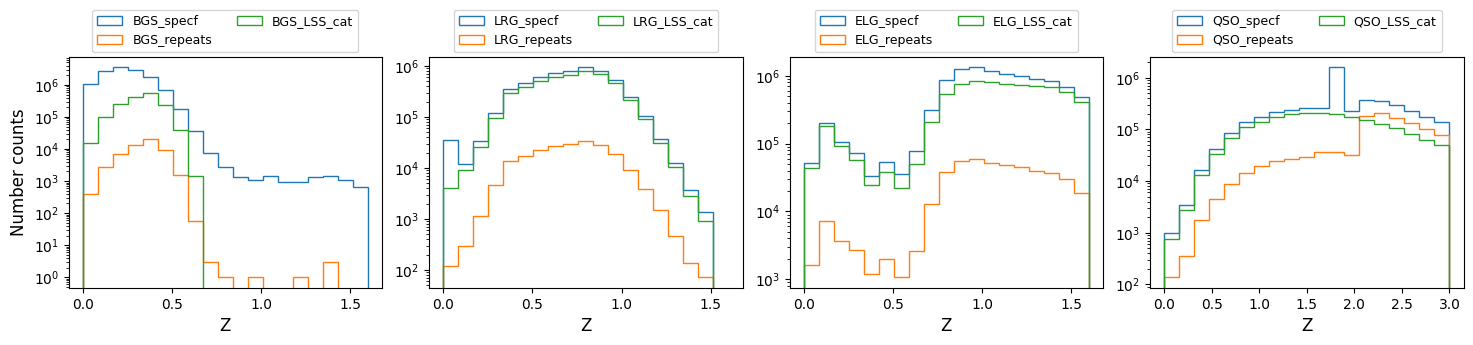

In [38]:
tracers = ['BGS', 'LRG','ELG','QSO']
specf_all = [specfb, specfl, specfe, specfq]
tr_all = [bgsr, lrgr, elgr, qsor]

bin_range = [[0,1.6],[0,1.6],[0,1.6],[0,3]]
bins_num = 30

fig = plt.figure(figsize=(18, 3))
gs = gridspec.GridSpec(1,4,wspace=0.15,hspace=0.05)
for idx, tracer, specfsab, tr in zip(range(len(tracers)), tracers, specf_all, tr_all):
    ax = plt.subplot(gs[idx])
    zcol = 'Z_QF' if tracer == 'QSO' else 'Z'
    target_ids = np.load(f'/pscratch/sd/s/shengyu/repeats/DA2/loa-v1/{tracer}_target_ids.npy')
    sel_lss = np.isin(tr['TARGETID'], target_ids)
    sel = np.isfinite(tr[f'{zcol}_1']) & np.isfinite(tr[f'{zcol}_2'])
    tr=tr[sel&sel_lss]
    ax.hist(specfsab[zcol], bins = np.linspace(bin_range[idx][0], bin_range[idx][1], bins_num), histtype='step', label=f'{tracer}_specf')
    ax.hist(tr[f'{zcol}_1'], bins = np.linspace(bin_range[idx][0], bin_range[idx][1], bins_num), histtype='step', label=f'{tracer}_repeats')
    # ax.hist(tr[f'{zcol}_2'], bins=20, histtype='step', label=f'{tracer}_repeats_2')
    path = '/dvs_ro/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/nonKP'
    if tracer =='BGS': 
        tracer_label = 'BGS_BRIGHT-21.35'
    elif tracer == 'ELG':
        tracer_label = 'ELG_LOPnotqso'
    else:
        tracer_label = tracer
    data = Table.read(path+f'/{tracer_label}_clustering.dat.fits')
    ax.hist(data['Z'], bins=np.linspace(bin_range[idx][0], bin_range[idx][1], bins_num), histtype='step', label = f'{tracer}_LSS_cat')
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.23), fontsize=9, ncol=2)
    # ax.legend(loc=1, fontsize=9)
    ax.set_xlabel('Z', fontsize=12)
    if idx == 0:
        ax.set_ylabel('Number counts', fontsize=12)
    ax.set_yscale('log')
save_fig = True
if save_fig == True:
    plt.savefig(OVERLEAF_DIR+f'/hist_repeats_compare_Z', dpi=400, bbox_inches='tight')

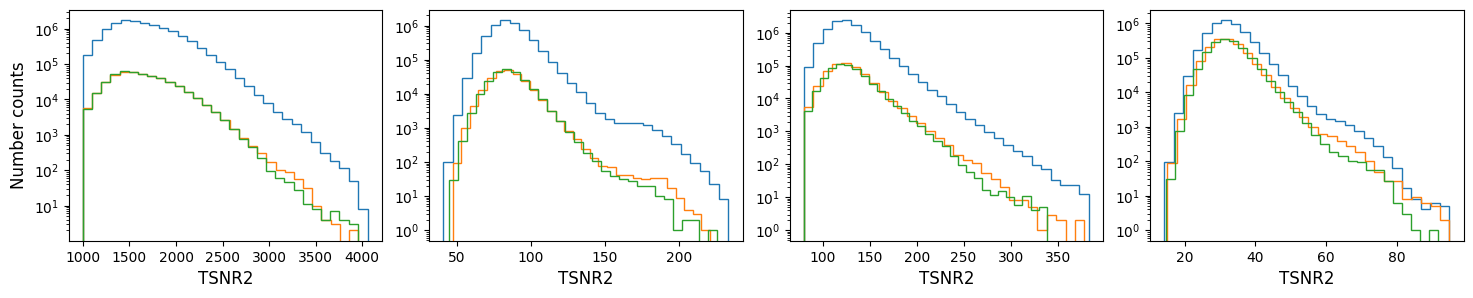

In [39]:
fig = plt.figure(figsize=(18, 3))
gs = gridspec.GridSpec(1,4,wspace=0.15,hspace=0.05)
for idx, tracer, specfsab, tr in zip(range(len(tracers)), tracers, specf_all, tr_all):
    ax = plt.subplot(gs[idx])
    ax.hist(specfsab[f'TSNR2_{tracer}'], bins=30, histtype='step', label=f'{tracer}_specf')
    ax.hist(tr[f'TSNR2_{tracer}_1'], bins=30, histtype='step', label=f'{tracer}_repeats_1')
    ax.hist(tr[f'TSNR2_{tracer}_2'], bins=30, histtype='step', label=f'{tracer}_repeats_2')
    # ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), fontsize=11, ncol=3)
    # ax.legend(loc=1, fontsize=9)
    ax.set_xlabel('TSNR2', fontsize=12)
    if idx == 0:
        ax.set_ylabel('Number counts', fontsize=12)
    ax.set_yscale('log')
if save_fig == True:
    plt.savefig(OVERLEAF_DIR+f'/hist_repeats_compare_TNSR2', dpi=400, bbox_inches='tight')

In [27]:
np.linspace(bin_range[idx][0], bin_range[idx][1], 20)

array([0.        , 0.07894737, 0.15789474, 0.23684211, 0.31578947,
       0.39473684, 0.47368421, 0.55263158, 0.63157895, 0.71052632,
       0.78947368, 0.86842105, 0.94736842, 1.02631579, 1.10526316,
       1.18421053, 1.26315789, 1.34210526, 1.42105263, 1.5       ])

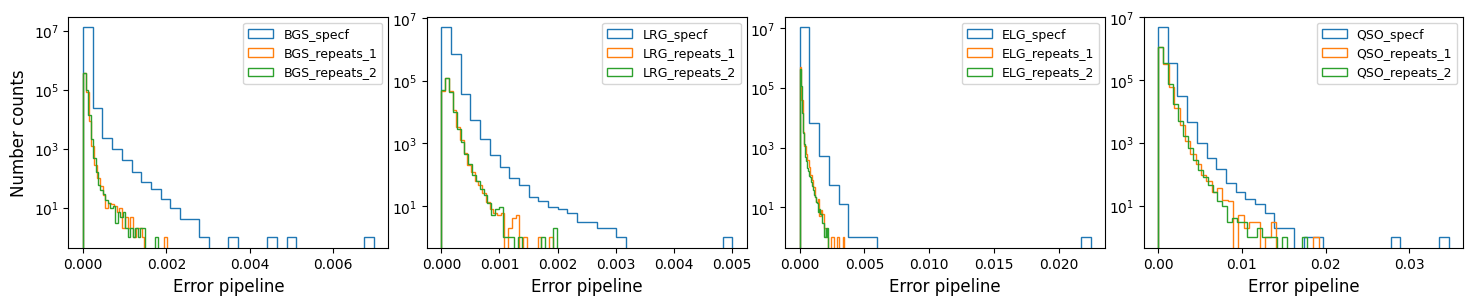

In [82]:
fig = plt.figure(figsize=(18, 3))
gs = gridspec.GridSpec(1,4,wspace=0.12,hspace=0.1)
for idx, tracer, specfsab, tr in zip(range(len(tracers)), tracers, specf_all, tr_all):
    ax = plt.subplot(gs[idx])
    ax.hist(specfsab[f'ZERR'], bins=30, histtype='step', label=f'{tracer}_specf')
    ax.hist(tr[f'ZERR_1'], bins=30, histtype='step', label=f'{tracer}_repeats_1')
    ax.hist(tr[f'ZERR_2'], bins=30, histtype='step', label=f'{tracer}_repeats_2')
    # ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), fontsize=11, ncol=3)
    ax.legend(loc=1, fontsize=9)
    ax.set_xlabel('Error pipeline', fontsize=12)
    if idx == 0:
        ax.set_ylabel('Number counts', fontsize=12)
    ax.set_yscale('log')

In [75]:
path = '/dvs_ro/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/nonKP'
data = Table.read(path+f'/{tracer}_clustering.dat.fits')
data

TARGETID,TILEID,NTILE,RA,DEC,PHOTSYS,Z,FRAC_TLOBS_TILES,WEIGHT_ZFAIL,WEIGHT_IMLIN,WEIGHT_SYS,WEIGHT,WEIGHT_COMP
int64,int64,int64,float64,float64,bytes1,float64,float64,float64,float64,float64,float64,float64
39627322701125813,1169,1,21.876410751633088,-19.44134382450835,S,2.4147343976888758,0.9862681744749596,1.1243407726287842,0.9795196056365967,0.9795196056365967,2.202627660412986,2.0
39627322701128888,1169,1,21.970054362083097,-19.41049376322168,S,3.0154471067835114,0.9862681744749596,1.0687103271484375,0.9795196056365967,0.9795196056365967,1.0468227181881957,1.0
39627322705320844,1169,1,22.165120364661878,-19.38537156552792,S,1.5724607556496883,0.9862681744749596,1.076799988746643,0.9924231767654419,0.9924231767654419,1.0686412655729356,1.0
39627322705321907,1169,1,22.19615939639026,-19.388861440289986,S,1.5291193759823845,0.9862681744749596,1.1011314392089844,0.9924231767654419,0.9924231767654419,1.0927883609360833,1.0
39627322709514577,1169,1,22.409658386562008,-19.388786997297064,S,1.7646240493186662,0.9862681744749596,1.1451902389526367,0.9896571040153503,0.9896571040153503,1.1333456554285135,1.0
39627323120558797,2446,1,48.434226224228084,-19.430134035993415,S,1.5424038141175873,0.9716981132075472,1.0,1.020554542541504,1.020554542541504,1.020554542541504,1.0
39627323124748972,2446,1,48.59381358198363,-19.38441935595103,S,2.451788726239304,0.9716981132075472,1.0125689506530762,0.9781806468963623,0.9781806468963623,0.9904753511769968,1.0
39627323342851641,7146,1,62.295351753885896,-19.37790424426939,S,1.4669453904413403,0.9808917197452229,1.0,0.9596964716911316,0.9596964716911316,0.9596964716911316,1.0
39627328392794748,1169,1,21.025564410792047,-19.157535498555323,S,1.3103705929578875,0.9862681744749596,1.0878766775131226,0.9915021657943726,0.9915021657943726,1.0786320818714472,1.0
